<a href="https://colab.research.google.com/github/JF11579/PSID_For_the_Rest_of_US/blob/main/Notebook_02_Main_Analysis_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 — Main Analysis
## PSID Intergenerational Homeownership & Education

**Purpose:** Estimate the relationship between parental homeownership in 1968 and two child outcomes:  
1. Educational attainment (years)  
2. Homeownership in 2023  

Both models use OLS (linear probability model for the binary homeownership outcome).  
**Reference group:** White males whose parents rented in 1968.  

**Input:** `psid_intergenerational_clean.csv` from Notebook 01.2  
**Outputs:** Regression tables (CSV), figures (PNG), summary stats (CSV)

---
## Section 0: Setup & Data Load

In [ ]:
# ── Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, HTML
import os

# ── Style ──
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# ── Paths ──
BASE = '/content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2'
DATA_DIR = f'{BASE}/data'
OUTPUT_DIR = f'{BASE}/outputs'

INPUT_FILE = f'{OUTPUT_DIR}/psid_intergenerational_clean.csv'

# ── Verify paths ──
if not os.path.exists(BASE):
    print(f'ERROR: BASE path not found: {BASE}')
    print('Check that Google Drive is mounted and the path is correct.')
    mydrive = '/content/drive/MyDrive'
    if os.path.exists(mydrive):
        print(f'\nContents of MyDrive root: {os.listdir(mydrive)[:20]}')
else:
    print(f'BASE path OK: {BASE}')
    print(f'Files in outputs/: {os.listdir(OUTPUT_DIR)}')

BASE path OK: /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2
Files in outputs/: ['psid_intergenerational_clean.csv', 'psid_intergenerational_clean_prefilt.csv', 'table2_education_regressions.csv', 'table3_homeownership_regressions.csv', 'fig2_homeownership_by_race.png', 'fig1_homeownership_by_parent_status.png', 'table3_homeownership_regression_plain.csv', 'table1_summary_stats.csv', 'table2_education_regression_plain.csv', 'fig3_coefficient_plots.png', 'fig4_education_by_race.png', 'family_size_distribution.png', 'cohort_analysis.png', 'Regression_Report.html']


In [ ]:
df = pd.read_csv(INPUT_FILE)
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (3560, 22)

Columns: ['child_id', 'parent_id', 'birth_year', 'child_sex', 'child_educ_yrs', 'child_homeowner_2023', 'parent_homeowner', 'parent_educ_yrs', 'parent_income_1968', 'parent_income_1968_log', 'race', 'state_1968', 'head_sex_1968', 'V103', 'V313', 'V81', 'V181', 'V93', 'V119', 'ER35152', 'ER82032', 'ER32000']


,child_id,parent_id,birth_year,child_sex,child_educ_yrs,child_homeowner_2023,parent_homeowner,parent_educ_yrs,parent_income_1968,parent_income_1968_log,...,head_sex_1968,V103,V313,V81,V181,V93,V119,ER35152,ER82032,ER32000
0,4007,4001,1961.0,2,12.0,1.0,1.0,7.0,6434.0,8.769352,...,1.0,1.0,2.0,6434.0,1.0,41.0,1.0,12,1.0,2
1,4007,4002,1961.0,2,12.0,1.0,1.0,7.0,6434.0,8.769352,...,1.0,1.0,2.0,6434.0,1.0,41.0,1.0,12,1.0,2
2,5003,5001,1963.0,1,12.0,1.0,1.0,10.0,7900.0,8.974618,...,1.0,1.0,3.0,7900.0,1.0,41.0,1.0,12,1.0,1
3,5004,5001,1966.0,2,12.0,0.0,1.0,10.0,7900.0,8.974618,...,1.0,1.0,3.0,7900.0,1.0,41.0,1.0,12,5.0,2
4,5005,5001,1967.0,1,10.0,1.0,1.0,10.0,7900.0,8.974618,...,1.0,1.0,3.0,7900.0,1.0,41.0,1.0,10,1.0,1


In [ ]:
# ── Variable prep ──
# Sex label for readability
df['sex_label'] = df['child_sex'].map({1: 'Male', 2: 'Female'})

# Confirm race is string
print('=== Race distribution ===')
print(df['race'].value_counts())
print(f'\n=== Sex distribution ===')
print(df['sex_label'].value_counts())
print(f'\n=== Parent homeowner ===')
print(df['parent_homeowner'].value_counts())
print(f'\n=== Missing values ===')
print(df.isnull().sum())

=== Race distribution ===
race
White       2195
Black       1326
Hispanic      26
Other         11
Name: count, dtype: int64

=== Sex distribution ===
sex_label
Female    2039
Male      1521
Name: count, dtype: int64

=== Parent homeowner ===
parent_homeowner
1.0    2225
0.0    1335
Name: count, dtype: int64

=== Missing values ===
child_id                   0
parent_id                  0
birth_year                 0
child_sex                  0
child_educ_yrs             0
child_homeowner_2023       0
parent_homeowner           0
parent_educ_yrs           32
parent_income_1968         0
parent_income_1968_log     0
race                       2
state_1968                 0
head_sex_1968              0
V103                       0
V313                       0
V81                        0
V181                       0
V93                        0
V119                       0
ER35152                    0
ER82032                    0
ER32000                    0
sex_label                  0

In [ ]:
# ── Create White/Black-only subsample for main analysis ──
# Hispanic (<20) and Other (<20) subsamples are too small for reliable inference
df_wb = df[df['race'].isin(['White', 'Black'])].copy()
print(f'Full sample: {len(df):,} observations')
print(f'White + Black only: {len(df_wb):,} observations')
print(f'Dropped (Hispanic/Other): {len(df) - len(df_wb):,} observations')
print(f'\nWhite/Black subsample race counts:')
print(df_wb['race'].value_counts())

Full sample: 3,560 observations
White + Black only: 3,521 observations
Dropped (Hispanic/Other): 39 observations

White/Black subsample race counts:
race
White    2195
Black    1326
Name: count, dtype: int64


---
## Section 1: Sample Description (Table 1)

In [ ]:
# ── Table 1: Summary Statistics (White + Black sample) ──
summary_vars = ['parent_homeowner', 'parent_educ_yrs', 'parent_income_1968',
                'parent_income_1968_log', 'child_educ_yrs', 'child_homeowner_2023']

table1 = df_wb[summary_vars].describe().T[['count', 'mean', 'std', 'min', 'max']]
table1.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Max']
table1['N'] = table1['N'].astype(int)

# Rename for readability
table1.index = ['Parent Homeowner (1=Yes)', 'Parent Education (years)',
                'Parent Income (1968 $)', 'Log Parent Income',
                'Child Education (years)', 'Child Homeowner 2023 (1=Yes)']

print('=== TABLE 1: Summary Statistics (White & Black Families) ===')
display(table1.round(3))

table1.round(3).to_csv(f'{OUTPUT_DIR}/table1_summary_stats.csv')
print(f'Saved to {OUTPUT_DIR}/table1_summary_stats.csv')

=== TABLE 1: Summary Statistics (White & Black Families) ===


,N,Mean,Std Dev,Min,Max
Parent Homeowner (1=Yes),3521,0.625,0.484,0.000,1.000
Parent Education (years),3491,10.637,3.939,3.000,18.000
Parent Income (1968 $),3521,9135.450,6095.930,275.000,65400.000
Log Parent Income,3521,8.904,0.695,5.617,11.088
Child Education (years),3521,13.782,2.161,4.000,17.000
Child Homeowner 2023 (1=Yes),3521,0.724,0.447,0.000,1.000


Saved to /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2/outputs/table1_summary_stats.csv


In [ ]:
# ── Table 1b: Summary Stats by Parent Homeownership ──
table1b = df_wb.groupby('parent_homeowner')[summary_vars].mean()
table1b.index = ['Parent: Renter', 'Parent: Owner']
table1b.columns = ['Homeowner (mean)', 'Parent Educ (yrs)', 'Parent Income ($)',
                    'Log Income', 'Child Educ (yrs)', 'Child Homeowner Rate']
print('=== TABLE 1b: Means by Parent Homeownership Status ===')
display(table1b.round(3))

=== TABLE 1b: Means by Parent Homeownership Status ===


,Homeowner (mean),Parent Educ (yrs),Parent Income ($),Log Income,Child Educ (yrs),Child Homeowner Rate
Parent: Renter,0.0,9.256,6191.503,8.522,13.166,0.589
Parent: Owner,1.0,11.466,10903.155,9.133,14.152,0.805


In [ ]:

# ── Crosstab: Parent Homeowner x Race ──
# ct_race = pd.crosstab(df_wb['race'], df_wb['parent_homeowner'], margins=True, normalize='index')
# ct_race.columns = ['Renter Rate', 'Homeowner Rate']
ct_race = pd.crosstab(df_wb['race'], df_wb['parent_homeowner'], normalize='index')
ct_race.columns = ['Renter Rate', 'Homeowner Rate']

print('=== Parent Homeownership Rate by Race ===')
display(ct_race.round(3))

=== Parent Homeownership Rate by Race ===


,Renter Rate,Homeowner Rate
race,,
Black,0.640,0.360
White,0.215,0.785


In [ ]:
# ── Homeownership Transition Matrix ──
ct_hw = pd.crosstab(df_wb['parent_homeowner'], df_wb['child_homeowner_2023'], margins=True)
ct_hw.index = ['Parent: Renter', 'Parent: Owner', 'Total']
ct_hw.columns = ['Child: Renter', 'Child: Owner', 'Total']
print('=== Homeownership Transition Matrix (Counts) ===')
display(ct_hw)

ct_hw_pct = pd.crosstab(df_wb['parent_homeowner'], df_wb['child_homeowner_2023'], normalize='index')
ct_hw_pct.index = ['Parent: Renter', 'Parent: Owner']
ct_hw_pct.columns = ['Child: Renter', 'Child: Owner']
print('\n=== Homeownership Transition Matrix (Row %) ===')
display(ct_hw_pct.round(3))

=== Homeownership Transition Matrix (Counts) ===


,Child: Renter,Child: Owner,Total
Parent: Renter,543,778,1321
Parent: Owner,428,1772,2200
Total,971,2550,3521



=== Homeownership Transition Matrix (Row %) ===


,Child: Renter,Child: Owner
Parent: Renter,0.411,0.589
Parent: Owner,0.195,0.805


---
## Section 2: Child Education Regressions (OLS)

**Reference group for all models:** White male whose parents rented in 1968.  
The intercept represents the predicted education for this reference person.

In [ ]:
# ── Prepare education analysis sample ──
educ_vars = ['child_educ_yrs', 'parent_homeowner', 'parent_educ_yrs',
             'parent_income_1968_log', 'race', 'child_sex']

df_educ = df_wb.dropna(subset=educ_vars).copy()
print(f'Education analysis sample: {len(df_educ):,} obs')
print(f'  (dropped {len(df_wb) - len(df_educ):,} with missing values)')

Education analysis sample: 3,491 obs
  (dropped 30 with missing values)


In [ ]:
# ── Model 1: Bivariate — parent_homeowner only ──
# Intercept = average education for children of RENTERS
# parent_homeowner = additional years for children of OWNERS
model1 = smf.ols('child_educ_yrs ~ parent_homeowner', data=df_educ).fit()
print('=== MODEL 1: Bivariate ===')
print(model1.summary2().tables[1].to_string())
print(f'\nR² = {model1.rsquared:.4f}   N = {int(model1.nobs)}')

=== MODEL 1: Bivariate ===
                      Coef.  Std.Err.           t         P>|t|     [0.025     0.975]
Intercept         13.173415  0.058202  226.340732  0.000000e+00  13.059302  13.287528
parent_homeowner   0.985155  0.073618   13.382014  7.287365e-40   0.840817   1.129494

R² = 0.0488   N = 3491


In [ ]:
# ── Model 2: With controls ──
# Reference: White Male whose parents rented
# C(race, Treatment(reference='White')) → baseline is White
# C(child_sex, Treatment(reference=1)) → baseline is Male
model2 = smf.ols(
    'child_educ_yrs ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1))',
    data=df_educ
).fit()
print('=== MODEL 2: With Controls ===')
print(model2.summary2().tables[1].to_string())
print(f'\nR² = {model2.rsquared:.4f}   Adj R² = {model2.rsquared_adj:.4f}   N = {int(model2.nobs)}')

=== MODEL 2: With Controls ===
                                                   Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
Intercept                                       7.868835  0.560863  14.029866  1.532624e-43  6.769182  8.968489
C(race, Treatment(reference="White"))[T.Black]  0.052195  0.089224   0.584995  5.585890e-01 -0.122741  0.227131
C(child_sex, Treatment(reference=1))[T.2]      -0.006203  0.066660  -0.093057  9.258636e-01 -0.136899  0.124493
parent_homeowner                                0.340009  0.076571   4.440411  9.257282e-06  0.189879  0.490138
parent_educ_yrs                                 0.185195  0.010284  18.008596  2.128901e-69  0.165032  0.205358
parent_income_1968_log                          0.417969  0.065722   6.359644  2.284963e-10  0.289111  0.546826

R² = 0.2065   Adj R² = 0.2053   N = 3491


In [ ]:
# ── Model 3: With controls + state fixed effects ──
model3 = smf.ols(
    'child_educ_yrs ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1)) '
    '+ C(state_1968)',
    data=df_educ
).fit()
print('=== MODEL 3: With Controls + State FE ===')
non_state = [v for v in model3.params.index if 'state' not in v]
print(model3.summary2().tables[1].loc[non_state].to_string())
print(f'\n(State fixed effects suppressed — {int(df_educ["state_1968"].nunique())} states)')
print(f'R² = {model3.rsquared:.4f}   Adj R² = {model3.rsquared_adj:.4f}   N = {int(model3.nobs)}')

=== MODEL 3: With Controls + State FE ===
                                                   Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
Intercept                                       7.202836  0.645528  11.158054  1.994463e-28  5.937180  8.468492
C(race, Treatment(reference="White"))[T.Black]  0.115721  0.106124   1.090432  2.755990e-01 -0.092351  0.323794
C(child_sex, Treatment(reference=1))[T.2]       0.029903  0.066896   0.447001  6.549022e-01 -0.101257  0.161062
parent_homeowner                                0.318515  0.079337   4.014699  6.078820e-05  0.162962  0.474068
parent_educ_yrs                                 0.180259  0.010566  17.060150  1.025939e-62  0.159543  0.200976
parent_income_1968_log                          0.536941  0.069949   7.676216  2.119266e-14  0.399796  0.674086

(State fixed effects suppressed — 37 states)
R² = 0.2342   Adj R² = 0.2251   N = 3491


In [ ]:
# ══════════════════════════════════════════════════════════════
# PLAIN ENGLISH SUMMARY — Education Models
# ══════════════════════════════════════════════════════════════

# Map statsmodels variable names to plain English
rename_educ = {
    'Intercept': 'Intercept (White Male, Parents Rented)',
    'parent_homeowner': 'Parent Owned Home (vs Rented)',
    'parent_educ_yrs': 'Parent Education (per year)',
    'parent_income_1968_log': 'Parent Income (log, 1968)',
    'C(race, Treatment(reference="White"))[T.Black]': 'Black (vs White)',
    'C(child_sex, Treatment(reference=1))[T.2]': 'Female (vs Male)',
}

def make_plain_table(model, rename_map, model_label):
    """Create a plain-English regression summary table."""
    params = model.params
    se = model.bse
    pval = model.pvalues
    ci = model.conf_int()

    rows = []
    for var, label in rename_map.items():
        if var in params.index:
            stars = '***' if pval[var] < 0.001 else '**' if pval[var] < 0.01 else '*' if pval[var] < 0.05 else ''
            rows.append({
                'Variable': label,
                'Coefficient': f'{params[var]:+.3f}{stars}',
                'Std Error': f'{se[var]:.3f}',
                'p-value': f'{pval[var]:.4f}',
                '95% CI': f'[{ci.loc[var, 0]:.3f}, {ci.loc[var, 1]:.3f}]'
            })

    tbl = pd.DataFrame(rows)
    # Add model stats
    stats = pd.DataFrame([{
        'Variable': 'R-squared',
        'Coefficient': f'{model.rsquared:.4f}',
        'Std Error': '', 'p-value': '',
        '95% CI': f'N = {int(model.nobs):,}'
    }])
    tbl = pd.concat([tbl, stats], ignore_index=True)
    tbl = tbl.set_index('Variable')
    return tbl

print('=' * 70)
print('EDUCATION RESULTS — PLAIN ENGLISH')
print('Reference group: White Male whose parents RENTED in 1968')
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')
print('=' * 70)
print('\nNOTE: In Models 2–3, the intercept is a mathematical baseline')
print('(all continuous controls set to 0), NOT a real-world average.')
print('Use Model 1 intercept for the actual average education of renters\' children.\n')

rename_m1 = {k: v for k, v in rename_educ.items() if k in model1.params.index}

print('\n── Model 1: Homeownership Only ──')
display(make_plain_table(model1, rename_m1, 'M1'))

print('\n── Model 2: With Controls ──')
display(make_plain_table(model2, rename_educ, 'M2'))

print('\n── Model 3: With Controls + State Fixed Effects ──')
display(make_plain_table(model3, rename_educ, 'M3'))

EDUCATION RESULTS — PLAIN ENGLISH
Reference group: White Male whose parents RENTED in 1968
Significance: * p<0.05  ** p<0.01  *** p<0.001

NOTE: In Models 2–3, the intercept is a mathematical baseline
(all continuous controls set to 0), NOT a real-world average.
Use Model 1 intercept for the actual average education of renters' children.


── Model 1: Homeownership Only ──


,Coefficient,Std Error,p-value,95% CI
Variable,,,,
"Intercept (White Male, Parents Rented)",+13.173***,0.058,0.0000,"[13.059, 13.288]"
Parent Owned Home (vs Rented),+0.985***,0.074,0.0000,"[0.841, 1.129]"
R-squared,0.0488,,,"N = 3,491"



── Model 2: With Controls ──


,Coefficient,Std Error,p-value,95% CI
Variable,,,,
"Intercept (White Male, Parents Rented)",+7.869***,0.561,0.0000,"[6.769, 8.968]"
Parent Owned Home (vs Rented),+0.340***,0.077,0.0000,"[0.190, 0.490]"
Parent Education (per year),+0.185***,0.010,0.0000,"[0.165, 0.205]"
"Parent Income (log, 1968)",+0.418***,0.066,0.0000,"[0.289, 0.547]"
Black (vs White),+0.052,0.089,0.5586,"[-0.123, 0.227]"
Female (vs Male),-0.006,0.067,0.9259,"[-0.137, 0.124]"
R-squared,0.2065,,,"N = 3,491"



── Model 3: With Controls + State Fixed Effects ──


,Coefficient,Std Error,p-value,95% CI
Variable,,,,
"Intercept (White Male, Parents Rented)",+7.203***,0.646,0.0000,"[5.937, 8.468]"
Parent Owned Home (vs Rented),+0.319***,0.079,0.0001,"[0.163, 0.474]"
Parent Education (per year),+0.180***,0.011,0.0000,"[0.160, 0.201]"
"Parent Income (log, 1968)",+0.537***,0.070,0.0000,"[0.400, 0.674]"
Black (vs White),+0.116,0.106,0.2756,"[-0.092, 0.324]"
Female (vs Male),+0.030,0.067,0.6549,"[-0.101, 0.161]"
R-squared,0.2342,,,"N = 3,491"


In [ ]:
# ── Narrative interpretation (education) ──
m2_hw = model2.params['parent_homeowner']
m2_hw_p = model2.pvalues['parent_homeowner']
m1_hw = model1.params['parent_homeowner']

race_var = 'C(race, Treatment(reference="White"))[T.Black]'
m2_black = model2.params.get(race_var, np.nan)
sex_var = 'C(child_sex, Treatment(reference=1))[T.2]'
m2_female = model2.params.get(sex_var, np.nan)

print('═' * 70)
print('HOW TO READ THESE RESULTS (for the book)')
print('═' * 70)
print(f'''
MODEL 1 (no controls):
  Children of renters averaged {model1.params["Intercept"]:.1f} years of education.
  Children of homeowners averaged {m1_hw:+.2f} years MORE — about {m1_hw:.1f} extra year.
  This is the raw, unadjusted gap.

MODEL 2 (with controls):
  After controlling for parent education, parent income, race, and sex:
  Parent homeownership is associated with {m2_hw:+.3f} years of additional education.
  {'This is statistically significant (p < 0.05).' if m2_hw_p < 0.05 else 'This is NOT statistically significant.'}

  The homeownership effect {'dropped from' if abs(m2_hw) < abs(m1_hw) else 'increased from'} \
{m1_hw:.2f} to {m2_hw:.2f} years once controls are added.
  This means {abs(m1_hw - m2_hw) / abs(m1_hw) * 100:.0f}% of the raw gap was explained by \
other family characteristics.

  Race: Black children received {m2_black:+.2f} years compared to White children,
  holding parent income, education, homeownership, and sex constant.

  Sex: Females received {m2_female:+.2f} years compared to Males,
  holding all else constant.
''')

══════════════════════════════════════════════════════════════════════
HOW TO READ THESE RESULTS (for the book)
══════════════════════════════════════════════════════════════════════

MODEL 1 (no controls):
  Children of renters averaged 13.2 years of education.
  Children of homeowners averaged +0.99 years MORE — about 1.0 extra year.
  This is the raw, unadjusted gap.

MODEL 2 (with controls):
  After controlling for parent education, parent income, race, and sex:
  Parent homeownership is associated with +0.340 years of additional education.
  This is statistically significant (p < 0.05).

  The homeownership effect dropped from 0.99 to 0.34 years once controls are added.
  This means 65% of the raw gap was explained by other family characteristics.

  Race: Black children received +0.05 years compared to White children,
  holding parent income, education, homeownership, and sex constant.

  Sex: Females received -0.01 years compared to Males,
  holding all else constant.



In [ ]:
# ── Save combined education regression table ──
educ_table = pd.concat([
    extract_coefs(model1, 'M1') if 'extract_coefs' in dir() else pd.DataFrame(),
], axis=1)

# Simpler approach: save plain English tables
plain_m2 = make_plain_table(model2, rename_educ, 'M2')
plain_m2.to_csv(f'{OUTPUT_DIR}/table2_education_regression_plain.csv')
print(f'Saved plain English education table to {OUTPUT_DIR}/table2_education_regression_plain.csv')

Saved plain English education table to /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2/outputs/table2_education_regression_plain.csv


---
## Section 3: Homeownership Transmission — Child Homeownership (LPM)

**LPM = Linear Probability Model.** Same as OLS but with a 0/1 outcome.  
Coefficients = change in probability (percentage points) of child owning a home in 2023.  
**Reference group:** White male whose parents rented in 1968.

In [ ]:
# ── Prepare homeownership analysis sample ──
homeown_vars = ['child_homeowner_2023', 'parent_homeowner', 'parent_educ_yrs',
                'parent_income_1968_log', 'race', 'child_sex']

df_homeown = df_wb.dropna(subset=homeown_vars).copy()
print(f'Homeownership analysis sample: {len(df_homeown):,} obs')
print(f'  (dropped {len(df_wb) - len(df_homeown):,} with missing values)')
print(f'\nOverall child homeownership rate: {df_homeown["child_homeowner_2023"].mean():.1%}')
print('  (i.e., {:.1%} of children in the sample own a home in 2023)'.format(
    df_homeown['child_homeowner_2023'].mean()))

Homeownership analysis sample: 3,491 obs
  (dropped 30 with missing values)

Overall child homeownership rate: 72.7%
  (i.e., 72.7% of children in the sample own a home in 2023)


In [ ]:
# ── Model 4: Bivariate LPM ──
# Intercept = homeownership rate for children of RENTERS
# parent_homeowner = additional probability (pp) for children of OWNERS
model4 = smf.ols('child_homeowner_2023 ~ parent_homeowner', data=df_homeown).fit()
print('=== MODEL 4: Bivariate LPM ===')
print(model4.summary2().tables[1].to_string())
print(f'\nR² = {model4.rsquared:.4f}   N = {int(model4.nobs)}')

=== MODEL 4: Bivariate LPM ===
                     Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
Intercept         0.592819  0.011977  49.497002  0.000000e+00  0.569337  0.616301
parent_homeowner  0.214697  0.015149  14.172140  2.268446e-44  0.184995  0.244399

R² = 0.0544   N = 3491


In [ ]:
# ── Model 5: LPM with controls ──
model5 = smf.ols(
    'child_homeowner_2023 ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1))',
    data=df_homeown
).fit()
print('=== MODEL 5: LPM With Controls ===')
print(model5.summary2().tables[1].to_string())
print(f'\nR² = {model5.rsquared:.4f}   Adj R² = {model5.rsquared_adj:.4f}   N = {int(model5.nobs)}')

=== MODEL 5: LPM With Controls ===
                                                   Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
Intercept                                       0.671976  0.123264  5.451531  5.340862e-08  0.430299  0.913652
C(race, Treatment(reference="White"))[T.Black] -0.189238  0.019609 -9.650478  9.135826e-22 -0.227684 -0.150791
C(child_sex, Treatment(reference=1))[T.2]      -0.054576  0.014650 -3.725293  1.981798e-04 -0.083300 -0.025852
parent_homeowner                                0.124552  0.016828  7.401283  1.681941e-13  0.091558  0.157547
parent_educ_yrs                                 0.001243  0.002260  0.549907  5.824185e-01 -0.003188  0.005674
parent_income_1968_log                          0.007401  0.014444  0.512385  6.084137e-01 -0.020919  0.035721

R² = 0.1002   Adj R² = 0.0989   N = 3491


In [ ]:
# ── Model 6: LPM with controls + state FE ──
model6 = smf.ols(
    'child_homeowner_2023 ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1)) '
    '+ C(state_1968)',
    data=df_homeown
).fit()
print('=== MODEL 6: LPM With Controls + State FE ===')
non_state_hw = [v for v in model6.params.index if 'state' not in v]
print(model6.summary2().tables[1].loc[non_state_hw].to_string())
print(f'\n(State fixed effects suppressed — {int(df_homeown["state_1968"].nunique())} states)')
print(f'R² = {model6.rsquared:.4f}   Adj R² = {model6.rsquared_adj:.4f}   N = {int(model6.nobs)}')

=== MODEL 6: LPM With Controls + State FE ===
                                                   Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
Intercept                                       0.518100  0.141980  3.649107  2.670513e-04  0.239727  0.796473
C(race, Treatment(reference="White"))[T.Black] -0.203922  0.023341 -8.736522  3.684574e-18 -0.249687 -0.158158
C(child_sex, Treatment(reference=1))[T.2]      -0.055506  0.014713 -3.772516  1.643234e-04 -0.084354 -0.026659
parent_homeowner                                0.102505  0.017450  5.874301  4.649267e-09  0.068292  0.136718
parent_educ_yrs                                 0.003114  0.002324  1.340132  1.802907e-01 -0.001442  0.007671
parent_income_1968_log                          0.036424  0.015385  2.367525  1.796240e-02  0.006260  0.066588

(State fixed effects suppressed — 37 states)
R² = 0.1303   Adj R² = 0.1199   N = 3491


In [ ]:
# ══════════════════════════════════════════════════════════════
# PLAIN ENGLISH SUMMARY — Homeownership Models
# ══════════════════════════════════════════════════════════════

rename_homeown = {
    'Intercept': 'Intercept (White Male, Parents Rented)',
    'parent_homeowner': 'Parent Owned Home (vs Rented)',
    'parent_educ_yrs': 'Parent Education (per year)',
    'parent_income_1968_log': 'Parent Income (log, 1968)',
    'C(race, Treatment(reference="White"))[T.Black]': 'Black (vs White)',
    'C(child_sex, Treatment(reference=1))[T.2]': 'Female (vs Male)',
}

print('=' * 70)
print('HOMEOWNERSHIP RESULTS — PLAIN ENGLISH')
print('Reference group: White Male whose parents RENTED in 1968')
print('Coefficients = change in PROBABILITY of owning a home in 2023')
print('  e.g., 0.15 means 15 percentage points more likely to own')
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')
print('=' * 70)
print('\nNOTE: In Models 5–6, the intercept is a mathematical baseline')
print('(all continuous controls set to 0), NOT a real-world average.')
print('Use Model 4 intercept for the actual homeownership rate of renters\' children.\n')

rename_m4 = {k: v for k, v in rename_homeown.items() if k in model4.params.index}

print('\n── Model 4: Homeownership Only ──')
display(make_plain_table(model4, rename_m4, 'M4'))

print('\n── Model 5: With Controls ──')
display(make_plain_table(model5, rename_homeown, 'M5'))

print('\n── Model 6: With Controls + State Fixed Effects ──')
display(make_plain_table(model6, rename_homeown, 'M6'))

HOMEOWNERSHIP RESULTS — PLAIN ENGLISH
Reference group: White Male whose parents RENTED in 1968
Coefficients = change in PROBABILITY of owning a home in 2023
  e.g., 0.15 means 15 percentage points more likely to own
Significance: * p<0.05  ** p<0.01  *** p<0.001

NOTE: In Models 5–6, the intercept is a mathematical baseline
(all continuous controls set to 0), NOT a real-world average.
Use Model 4 intercept for the actual homeownership rate of renters' children.


── Model 4: Homeownership Only ──


,Coefficient,Std Error,p-value,95% CI
Variable,,,,
"Intercept (White Male, Parents Rented)",+0.593***,0.012,0.0000,"[0.569, 0.616]"
Parent Owned Home (vs Rented),+0.215***,0.015,0.0000,"[0.185, 0.244]"
R-squared,0.0544,,,"N = 3,491"



── Model 5: With Controls ──


,Coefficient,Std Error,p-value,95% CI
Variable,,,,
"Intercept (White Male, Parents Rented)",+0.672***,0.123,0.0000,"[0.430, 0.914]"
Parent Owned Home (vs Rented),+0.125***,0.017,0.0000,"[0.092, 0.158]"
Parent Education (per year),+0.001,0.002,0.5824,"[-0.003, 0.006]"
"Parent Income (log, 1968)",+0.007,0.014,0.6084,"[-0.021, 0.036]"
Black (vs White),-0.189***,0.020,0.0000,"[-0.228, -0.151]"
Female (vs Male),-0.055***,0.015,0.0002,"[-0.083, -0.026]"
R-squared,0.1002,,,"N = 3,491"



── Model 6: With Controls + State Fixed Effects ──


,Coefficient,Std Error,p-value,95% CI
Variable,,,,
"Intercept (White Male, Parents Rented)",+0.518***,0.142,0.0003,"[0.240, 0.796]"
Parent Owned Home (vs Rented),+0.103***,0.017,0.0000,"[0.068, 0.137]"
Parent Education (per year),+0.003,0.002,0.1803,"[-0.001, 0.008]"
"Parent Income (log, 1968)",+0.036*,0.015,0.0180,"[0.006, 0.067]"
Black (vs White),-0.204***,0.023,0.0000,"[-0.250, -0.158]"
Female (vs Male),-0.056***,0.015,0.0002,"[-0.084, -0.027]"
R-squared,0.1303,,,"N = 3,491"


In [ ]:
# ── Narrative interpretation (homeownership) ──
m4_int = model4.params['Intercept']
m4_hw = model4.params['parent_homeowner']
m5_hw = model5.params['parent_homeowner']
m5_hw_p = model5.pvalues['parent_homeowner']

race_var_hw = 'C(race, Treatment(reference="White"))[T.Black]'
m5_black = model5.params.get(race_var_hw, np.nan)
sex_var_hw = 'C(child_sex, Treatment(reference=1))[T.2]'
m5_female = model5.params.get(sex_var_hw, np.nan)

print('═' * 70)
print('HOW TO READ THESE RESULTS (for the book)')
print('═' * 70)
print(f'''
MODEL 4 (no controls):
  {m4_int:.1%} of children whose parents RENTED went on to own a home.
  Children of OWNERS were {m4_hw*100:+.1f} percentage points MORE likely to own
  — so about {(m4_int + m4_hw):.1%} of owners' children became homeowners.

MODEL 5 (with controls):
  After controlling for parent education, income, race, and sex:
  Parent homeownership is associated with a {m5_hw*100:+.1f} pp
  increase in the probability of child homeownership.
  {'This is statistically significant (p < 0.05).' if m5_hw_p < 0.05 else 'This is NOT statistically significant.'}

  The effect {'shrank from' if abs(m5_hw) < abs(m4_hw) else 'grew from'} \
{m4_hw*100:.1f} to {m5_hw*100:.1f} pp after adding controls.

  Race: Black children were {m5_black*100:+.1f} pp {'less' if m5_black < 0 else 'more'} likely
  to own a home than White children, holding all else constant.
  This large gap even after controls points to structural barriers
  (lending discrimination, segregation, wealth gaps not captured by income).

  Sex: Females were {m5_female*100:+.1f} pp {'less' if m5_female < 0 else 'more'} likely
  to own than Males, holding all else constant.
''')

══════════════════════════════════════════════════════════════════════
HOW TO READ THESE RESULTS (for the book)
══════════════════════════════════════════════════════════════════════

MODEL 4 (no controls):
  59.3% of children whose parents RENTED went on to own a home.
  Children of OWNERS were +21.5 percentage points MORE likely to own
  — so about 80.8% of owners' children became homeowners.

MODEL 5 (with controls):
  After controlling for parent education, income, race, and sex:
  Parent homeownership is associated with a +12.5 pp
  increase in the probability of child homeownership.
  This is statistically significant (p < 0.05).

  The effect shrank from 21.5 to 12.5 pp after adding controls.

  Race: Black children were -18.9 pp less likely
  to own a home than White children, holding all else constant.
  This large gap even after controls points to structural barriers
  (lending discrimination, segregation, wealth gaps not captured by income).

  Sex: Females were -5.5 pp less

In [ ]:
# ── Save plain English homeownership table ──
plain_m5 = make_plain_table(model5, rename_homeown, 'M5')
plain_m5.to_csv(f'{OUTPUT_DIR}/table3_homeownership_regression_plain.csv')
print(f'Saved to {OUTPUT_DIR}/table3_homeownership_regression_plain.csv')

Saved to /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2/outputs/table3_homeownership_regression_plain.csv


---
## Section 4: Figures

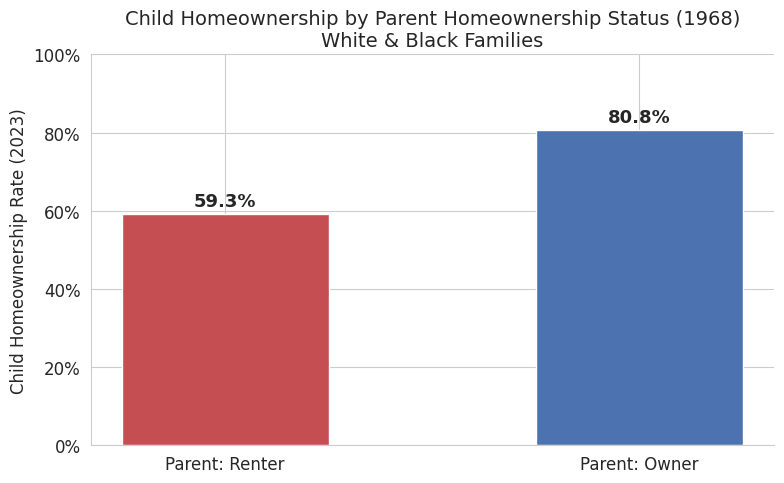

Saved fig1


In [ ]:
# ── Figure 1: Child Homeownership Rate by Parent Status ──
fig1, ax1 = plt.subplots(figsize=(8, 5))

hw_rates = df_homeown.groupby('parent_homeowner')['child_homeowner_2023'].mean()
bars = ax1.bar(['Parent: Renter', 'Parent: Owner'], hw_rates.values,
               color=['#c44e52', '#4c72b0'], width=0.5, edgecolor='white')

for bar, val in zip(bars, hw_rates.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.1%}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax1.set_ylabel('Child Homeownership Rate (2023)')
ax1.set_title('Child Homeownership by Parent Homeownership Status (1968)\nWhite & Black Families')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylim(0, 1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
fig1.savefig(f'{OUTPUT_DIR}/fig1_homeownership_by_parent_status.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig1')

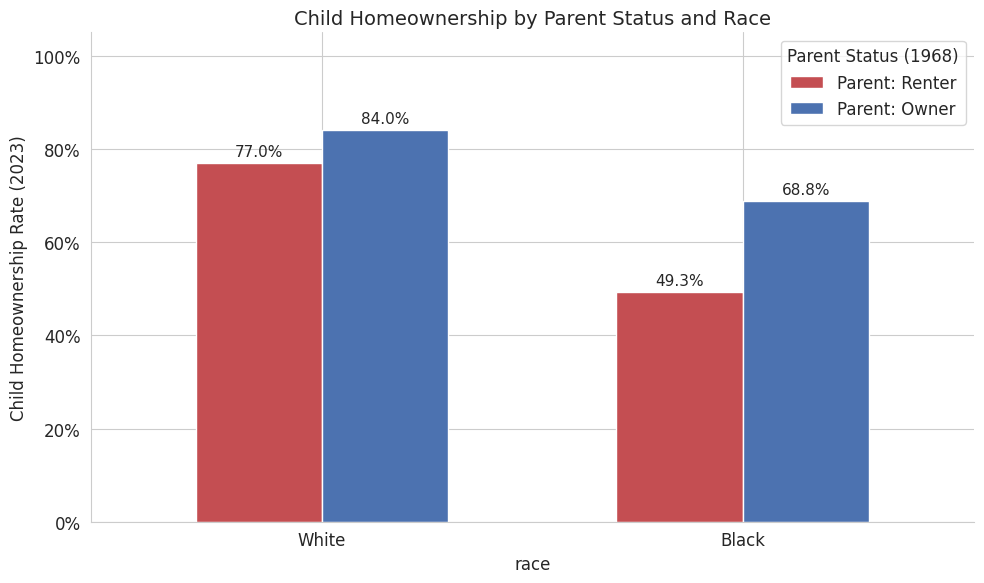

Saved fig2


In [ ]:
# ── Figure 2: Child Homeownership by Parent Status AND Race ──
fig2, ax2 = plt.subplots(figsize=(10, 6))

hw_by_race = df_homeown.groupby(['race', 'parent_homeowner'])['child_homeowner_2023'].mean().unstack()
hw_by_race.columns = ['Parent: Renter', 'Parent: Owner']
race_order = [r for r in ['White', 'Black'] if r in hw_by_race.index]
hw_by_race = hw_by_race.loc[race_order]

hw_by_race.plot(kind='bar', ax=ax2, color=['#c44e52', '#4c72b0'],
                width=0.6, edgecolor='white')

# Add value labels
for container in ax2.containers:
    labels = [f'{v.get_height():.1%}' for v in container]
    ax2.bar_label(container, labels=labels, label_type='edge', fontsize=11,
                  padding=3)

ax2.set_ylabel('Child Homeownership Rate (2023)')
ax2.set_title('Child Homeownership by Parent Status and Race')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylim(0, 1.05)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Parent Status (1968)', loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
fig2.savefig(f'{OUTPUT_DIR}/fig2_homeownership_by_race.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig2')

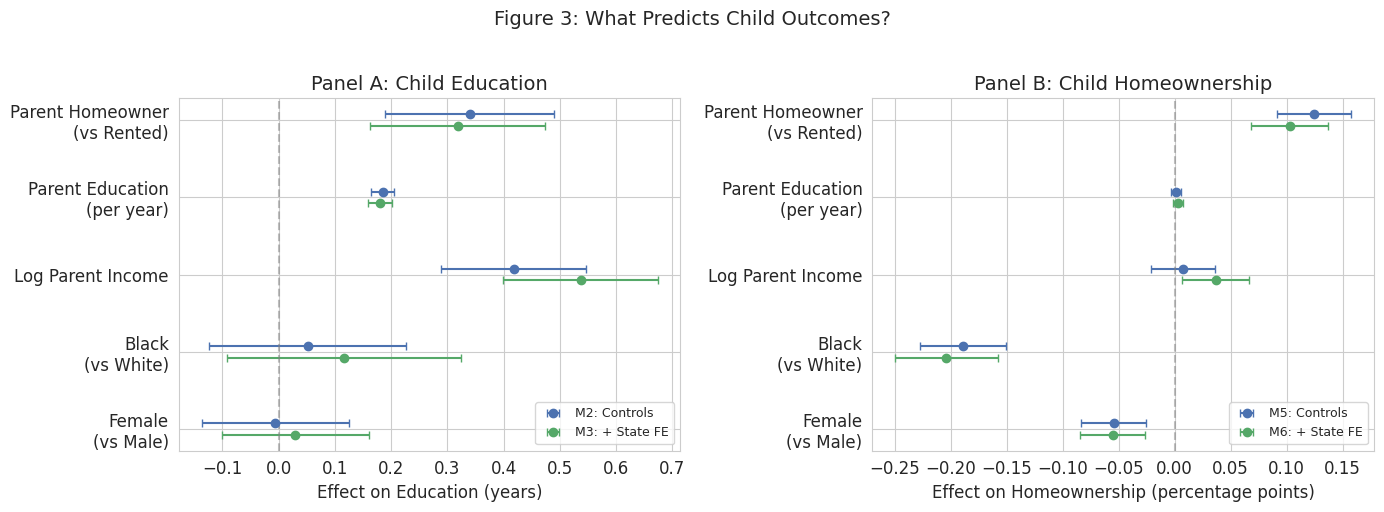

Saved fig3


In [ ]:
# ── Figure 3: Coefficient Plot — Education and Homeownership ──
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_vars = ['parent_homeowner', 'parent_educ_yrs', 'parent_income_1968_log',
             'C(race, Treatment(reference="White"))[T.Black]',
             'C(child_sex, Treatment(reference=1))[T.2]']
plot_labels = ['Parent Homeowner\n(vs Rented)', 'Parent Education\n(per year)',
               'Log Parent Income', 'Black\n(vs White)', 'Female\n(vs Male)']

# --- Panel A: Education ---
for i, (model, color, label) in enumerate([
    (model2, '#4c72b0', 'M2: Controls'),
    (model3, '#55a868', 'M3: + State FE')
]):
    available = [v for v in plot_vars if v in model.params.index]
    avail_labels = [plot_labels[plot_vars.index(v)] for v in available]
    coefs = model.params[available]
    cis = model.conf_int().loc[available]
    y_pos = np.arange(len(available)) + i * 0.15
    axes[0].errorbar(coefs, y_pos, xerr=[coefs - cis[0], cis[1] - coefs],
                     fmt='o', color=color, label=label, capsize=3, markersize=6)

axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_yticks(np.arange(len(available)) + 0.075)
axes[0].set_yticklabels(avail_labels)
axes[0].set_xlabel('Effect on Education (years)')
axes[0].set_title('Panel A: Child Education')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].invert_yaxis()

# --- Panel B: Homeownership ---
for i, (model, color, label) in enumerate([
    (model5, '#4c72b0', 'M5: Controls'),
    (model6, '#55a868', 'M6: + State FE')
]):
    available = [v for v in plot_vars if v in model.params.index]
    avail_labels = [plot_labels[plot_vars.index(v)] for v in available]
    coefs = model.params[available]
    cis = model.conf_int().loc[available]
    y_pos = np.arange(len(available)) + i * 0.15
    axes[1].errorbar(coefs, y_pos, xerr=[coefs - cis[0], cis[1] - coefs],
                     fmt='o', color=color, label=label, capsize=3, markersize=6)

axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_yticks(np.arange(len(available)) + 0.075)
axes[1].set_yticklabels(avail_labels)
axes[1].set_xlabel('Effect on Homeownership (percentage points)')
axes[1].set_title('Panel B: Child Homeownership')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].invert_yaxis()

plt.suptitle('Figure 3: What Predicts Child Outcomes?', y=1.02, fontsize=14)
plt.tight_layout()
fig3.savefig(f'{OUTPUT_DIR}/fig3_coefficient_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig3')

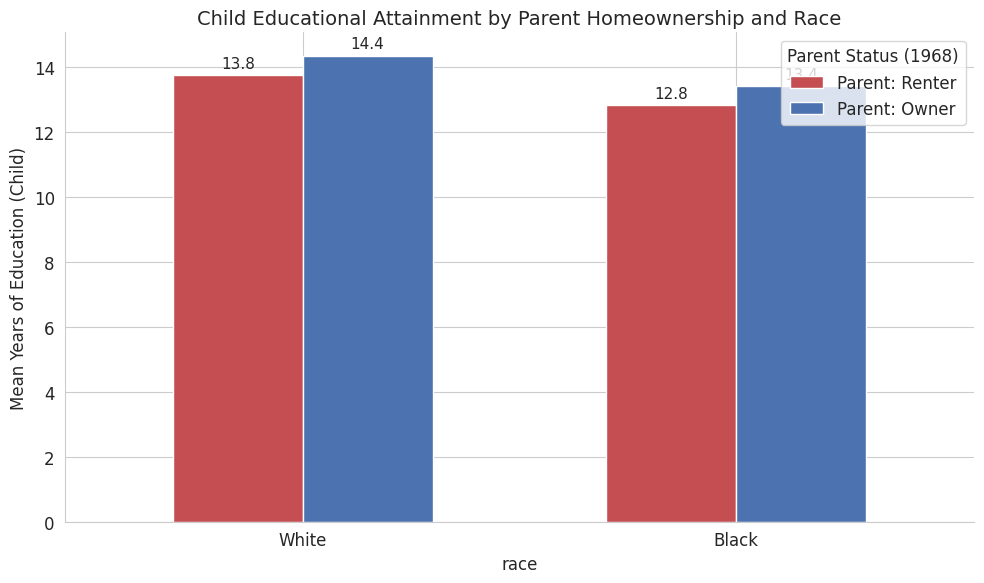

Saved fig4


In [ ]:
# ── Figure 4: Mean Child Education by Parent Homeownership and Race ──
fig4, ax4 = plt.subplots(figsize=(10, 6))

educ_by_race = df_educ.groupby(['race', 'parent_homeowner'])['child_educ_yrs'].mean().unstack()
educ_by_race.columns = ['Parent: Renter', 'Parent: Owner']
educ_by_race = educ_by_race.loc[[r for r in ['White', 'Black'] if r in educ_by_race.index]]

educ_by_race.plot(kind='bar', ax=ax4, color=['#c44e52', '#4c72b0'],
                  width=0.6, edgecolor='white')

for container in ax4.containers:
    ax4.bar_label(container, fmt='%.1f', label_type='edge', fontsize=11, padding=3)

ax4.set_ylabel('Mean Years of Education (Child)')
ax4.set_title('Child Educational Attainment by Parent Homeownership and Race')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.legend(title='Parent Status (1968)', loc='upper right')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
fig4.savefig(f'{OUTPUT_DIR}/fig4_education_by_race.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig4')

---
## Section 5: Robustness — Full Sample Including Hispanic & Other

The main analysis above uses only White and Black families because the PSID's 1968 sample  
was designed around these two groups. Hispanic and Other subsamples have fewer than 40  
observations each, making their coefficients unreliable.  

This section re-runs the key models on the full sample to confirm that results are  
substantively similar. These can be cited in a footnote.

In [ ]:
# ── Full-sample robustness (all races) ──
df_full = df.dropna(subset=educ_vars).copy()
print(f'Full sample (all races): {len(df_full):,} obs')
print(f'Race distribution:')
print(df_full['race'].value_counts())

# Education model with controls
model2_full = smf.ols(
    'child_educ_yrs ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1))',
    data=df_full
).fit()

# Homeownership model with controls
df_full_hw = df.dropna(subset=homeown_vars).copy()
model5_full = smf.ols(
    'child_homeowner_2023 ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1))',
    data=df_full_hw
).fit()

print('\n=== ROBUSTNESS: Education Model (Full Sample) ===')
print(f'Parent homeowner coeff: {model2_full.params["parent_homeowner"]:+.3f}')
print(f'  (Main analysis: {model2.params["parent_homeowner"]:+.3f})')

print(f'\n=== ROBUSTNESS: Homeownership Model (Full Sample) ===')
print(f'Parent homeowner coeff: {model5_full.params["parent_homeowner"]:+.3f}')
print(f'  (Main analysis: {model5.params["parent_homeowner"]:+.3f})')

print('\n→ If coefficients are similar, this confirms that dropping Hispanic/Other')
print('  does not materially change the findings.')

Full sample (all races): 3,526 obs
Race distribution:
race
White       2187
Black       1304
Hispanic      24
Other         11
Name: count, dtype: int64

=== ROBUSTNESS: Education Model (Full Sample) ===
Parent homeowner coeff: +0.337
  (Main analysis: +0.340)

=== ROBUSTNESS: Homeownership Model (Full Sample) ===
Parent homeowner coeff: +0.128
  (Main analysis: +0.125)

→ If coefficients are similar, this confirms that dropping Hispanic/Other
  does not materially change the findings.


---
## Section 6: Export Summary

In [ ]:
print('=' * 60)
print('NOTEBOOK 02 — OUTPUT SUMMARY')
print('=' * 60)
print(f'\nSample: White & Black families only (N = {len(df_wb):,})')
print(f'\nTables saved to {OUTPUT_DIR}/:')
print(f'  table1_summary_stats.csv')
print(f'  table2_education_regression_plain.csv')
print(f'  table3_homeownership_regression_plain.csv')
print(f'\nFigures saved to {OUTPUT_DIR}/:')
print(f'  fig1_homeownership_by_parent_status.png')
print(f'  fig2_homeownership_by_race.png')
print(f'  fig3_coefficient_plots.png')
print(f'  fig4_education_by_race.png')
print('\n--- KEY FINDINGS ---')
print(f'Education sample: {int(model1.nobs):,} | Homeownership sample: {int(model4.nobs):,}')
print(f'\nEDUCATION (child years of schooling):')
print(f'  Raw gap (owners vs renters):        {model1.params["parent_homeowner"]:+.2f} years')
print(f'  After controls:                     {model2.params["parent_homeowner"]:+.2f} years')
print(f'  After controls + state FE:          {model3.params["parent_homeowner"]:+.2f} years')
print(f'\nHOMEOWNERSHIP (prob. child owns in 2023):')
print(f'  Raw gap (owners vs renters):        {model4.params["parent_homeowner"]:+.2f} pp')
print(f'  After controls:                     {model5.params["parent_homeowner"]:+.2f} pp')
print(f'  After controls + state FE:          {model6.params["parent_homeowner"]:+.2f} pp')

NOTEBOOK 02 — OUTPUT SUMMARY

Sample: White & Black families only (N = 3,521)

Tables saved to /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2/outputs/:
  table1_summary_stats.csv
  table2_education_regression_plain.csv
  table3_homeownership_regression_plain.csv

Figures saved to /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2/outputs/:
  fig1_homeownership_by_parent_status.png
  fig2_homeownership_by_race.png
  fig3_coefficient_plots.png
  fig4_education_by_race.png

--- KEY FINDINGS ---
Education sample: 3,491 | Homeownership sample: 3,491

EDUCATION (child years of schooling):
  Raw gap (owners vs renters):        +0.99 years
  After controls:                     +0.34 years
  After controls + state FE:          +0.32 years

HOMEOWNERSHIP (prob. child owns in 2023):
  Raw gap (owners vs renters):        +0.21 pp
  After controls:                     +0.12 pp
  After controls + state FE:          +0.10 pp


# ############
